In [2]:
import os
import math
import time
import random
from typing import Tuple, Dict, List
from dataclasses import dataclass
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split, Subset
import torchvision
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.transforms import InterpolationMode
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights
from torchvision.transforms import functional as F
import pandas as pd
import json

In [3]:
def set_seed(seed: int = 123) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

RANDOM_STATE = 123
set_seed(RANDOM_STATE)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
DATA_DIR = "./data"
BATCH_SIZE = 64
EPOCHS = 8

Device: cpu


In [4]:
STL10_MEAN = (0.485, 0.456, 0.406)
STL10_STD  = (0.229, 0.224, 0.225)

IMG_SIZE = 100

tf_train = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(STL10_MEAN, STL10_STD),
])
tf_test = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(STL10_MEAN, STL10_STD),
])
train_tf_aug = transforms.Compose([
    transforms.Resize(IMG_SIZE + 32),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(STL10_MEAN, STL10_STD),
])

eval_tf = transforms.Compose([
    transforms.Resize(IMG_SIZE + 32),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(STL10_MEAN, STL10_STD),
])

def load_stl10_tl(data_dir: str = DATA_DIR):
    ds_train_aug = torchvision.datasets.STL10(root=data_dir, split="train", download=True, transform=train_tf_aug)
    ds_train_eval_aug = torchvision.datasets.STL10(root=data_dir, split="train", download=True, transform=eval_tf)
    ds_test_aug = torchvision.datasets.STL10(root=data_dir, split="test", download=True, transform=eval_tf)
    ds_train = torchvision.datasets.STL10(root=data_dir, split="train", download=True, transform=tf_train)
    ds_test = torchvision.datasets.STL10(root=data_dir, split="test", download=True, transform=tf_test)
    return ds_train_aug, ds_train_eval_aug, ds_test_aug, ds_train, ds_test

ds_train_aug, ds_train_eval, ds_test_aug, ds_train, ds_test = load_stl10_tl()
class_names = ds_train_aug.classes

print(len(class_names))
print("Train full:", len(ds_train_aug))
print("Test:", len(ds_test))

100%|██████████| 2.64G/2.64G [04:23<00:00, 10.0MB/s]


10
Train full: 5000
Test: 8000


In [8]:
NUM_CLASSES = len(class_names)
NUM_WORKERS = 0 if os.name == "nt" else 2

def make_loaders_tl(
    ds_train_aug_full,
    ds_train_eval_full,
    ds_test_aug,
    ds_train_full,
    ds_test,
    batch_size: int = BATCH_SIZE,
    val_ratio: float = 0.2,
    seed: int = RANDOM_STATE,
):
    n_total = len(ds_train_aug_full)
    n_val = int(n_total * val_ratio)

    rng = np.random.RandomState(seed)
    indices = np.arange(n_total)
    rng.shuffle(indices)

    val_idx = indices[:n_val]
    train_idx = indices[n_val:]

    ds_train_aug = Subset(ds_train_aug_full, train_idx)
    ds_val_aug = Subset(ds_train_eval_full, val_idx)

    ds_train_plain = Subset(ds_train_full, train_idx)
    ds_val_plain = Subset(ds_train_full, val_idx)

    train_idx2 = rng.choice(len(ds_train_aug), size=min(4000, len(ds_train_aug)), replace=False)
    val_idx2 = rng.choice(len(ds_val_aug), size=min(1000, len(ds_val_aug)), replace=False)
    test_idx2 = rng.choice(len(ds_test_aug), size=min(1000, len(ds_test_aug)), replace=False)
    test_plain_idx2 = rng.choice(len(ds_test), size=min(1000, len(ds_test)), replace=False)

    ds_train_aug = Subset(ds_train_aug, train_idx2)
    ds_val_aug = Subset(ds_val_aug, val_idx2)
    ds_test_aug_small = Subset(ds_test_aug, test_idx2)

    ds_train_plain = Subset(ds_train_plain, train_idx2)
    ds_val_plain = Subset(ds_val_plain, val_idx2)
    ds_test_plain_small = Subset(ds_test, test_plain_idx2)

    train_loader_aug = DataLoader(ds_train_aug, batch_size=batch_size, shuffle=True, num_workers=NUM_WORKERS, pin_memory=False)
    val_loader_aug = DataLoader(ds_val_aug, batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS, pin_memory=False)
    test_loader_aug = DataLoader(ds_test_aug_small, batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS, pin_memory=False)

    train_loader = DataLoader(ds_train_plain, batch_size=batch_size, shuffle=True, num_workers=NUM_WORKERS, pin_memory=False)
    val_loader = DataLoader(ds_val_plain, batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS, pin_memory=False)
    test_loader = DataLoader(ds_test_plain_small, batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS, pin_memory=False)

    return (train_loader_aug, val_loader_aug, test_loader_aug, train_loader, val_loader, test_loader)

train_loader_aug, val_loader_aug, test_loader_aug, train_loader, val_loader, test_loader = make_loaders_tl(ds_train_aug, ds_train_eval, ds_test_aug, ds_train, ds_test)

loaders = {
    "train_loader_aug": train_loader_aug,
    "val_loader_aug": val_loader_aug,
    "test_loader_aug": test_loader_aug,
    "train_loader": train_loader,
    "val_loader": val_loader,
    "test_loader": test_loader,
}

for name, loader in loaders.items():
    x, y = next(iter(loader))
    print(f"{name}:")
    print("  x:", x.shape, x.dtype)
    print("  y:", y.shape, y.dtype)

train_loader_aug:
  x: torch.Size([64, 3, 100, 100]) torch.float32
  y: torch.Size([64]) torch.int64
val_loader_aug:
  x: torch.Size([64, 3, 100, 100]) torch.float32
  y: torch.Size([64]) torch.int64
test_loader_aug:
  x: torch.Size([64, 3, 100, 100]) torch.float32
  y: torch.Size([64]) torch.int64
train_loader:
  x: torch.Size([64, 3, 100, 100]) torch.float32
  y: torch.Size([64]) torch.int64
val_loader:
  x: torch.Size([64, 3, 100, 100]) torch.float32
  y: torch.Size([64]) torch.int64
test_loader:
  x: torch.Size([64, 3, 100, 100]) torch.float32
  y: torch.Size([64]) torch.int64


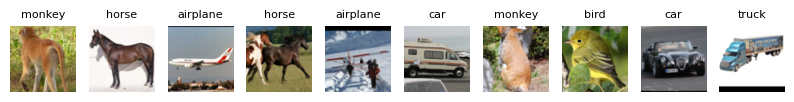

In [9]:
def denorm_stl10(x: torch.Tensor) -> torch.Tensor:
    mean = torch.tensor(STL10_MEAN).view(3, 1, 1)
    std = torch.tensor(STL10_STD).view(3, 1, 1)
    return x * std + mean

@torch.no_grad()
def show_images(loader, n: int = 10) -> None:
    x, y = next(iter(loader))
    x = x[:n].cpu()
    y = y[:n].cpu()

    plt.figure(figsize=(10, 2))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        img = denorm_stl10(x[i]).clamp(0, 1).permute(1, 2, 0).numpy()
        plt.imshow(img)
        plt.title(class_names[y[i].item()], fontsize=8)
        plt.axis("off")
    plt.show()

show_images(train_loader, n=10)

In [10]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)
IMG_SIZE = 100

train_img_tf = transforms.Compose([
    transforms.Resize(IMG_SIZE + 32, interpolation=InterpolationMode.BILINEAR),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0), interpolation=InterpolationMode.BILINEAR),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_mask_tf = transforms.Compose([
    transforms.Resize(IMG_SIZE + 32, interpolation=InterpolationMode.NEAREST),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0), interpolation=InterpolationMode.NEAREST),
    transforms.RandomHorizontalFlip(p=0.5),
])

eval_img_tf = transforms.Compose([
    transforms.Resize(IMG_SIZE + 32, interpolation=InterpolationMode.BILINEAR),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_mask_tf = transforms.Compose([
    transforms.Resize(IMG_SIZE + 32, interpolation=InterpolationMode.NEAREST),
    transforms.CenterCrop(IMG_SIZE),
])

class JointTransform:
    def __init__(self, img_tf, mask_tf):
        self.img_tf = img_tf
        self.mask_tf = mask_tf

    def __call__(self, img, mask):
        state = torch.get_rng_state()

        img = self.img_tf(img)

        torch.set_rng_state(state)
        mask = self.mask_tf(mask)

        mask = torch.as_tensor(np.array(mask), dtype=torch.int64)
        return img, mask

def load_vocseg_tl(data_dir: str, year: str = "2012"):
    ds_train = torchvision.datasets.VOCSegmentation(
        root=data_dir,
        year=year,
        image_set="train",
        download=True,
        transforms=JointTransform(train_img_tf, train_mask_tf),
    )
    ds_val = torchvision.datasets.VOCSegmentation(
        root=data_dir,
        year=year,
        image_set="val",
        download=True,
        transforms=JointTransform(eval_img_tf, eval_mask_tf),
    )

    ds_test = None
    if year == "2007":
        ds_test = torchvision.datasets.VOCSegmentation(
            root=data_dir,
            year=year,
            image_set="test",
            download=True,
            transforms=JointTransform(eval_img_tf, eval_mask_tf),
        )

    return ds_train, ds_val, ds_test

In [11]:
DATA_DIR = "./data"
ds_train, ds_val, ds_test = load_vocseg_tl(DATA_DIR, year="2012")

print("Train:", len(ds_train))
print("Val:", len(ds_val))
print("Test:", None if ds_test is None else len(ds_test))

x, y = ds_train[0]
print("x:", x.shape, x.dtype)
print("y:", y.shape, y.dtype, "labels:", int(y.min()), int(y.max()))

100%|██████████| 2.00G/2.00G [00:54<00:00, 37.0MB/s]


Train: 1464
Val: 1449
Test: None
x: torch.Size([3, 100, 100]) torch.float32
y: torch.Size([100, 100]) torch.int64 labels: 0 255


In [12]:
def make_loaders_voc_official(
    ds_train,
    ds_val,
    batch_size: int = BATCH_SIZE,
    test_ratio_from_val: float = 0.5,
    seed: int = RANDOM_STATE,
):
    n_val_total = len(ds_val)
    n_test = int(n_val_total * test_ratio_from_val)

    rng = np.random.RandomState(seed)
    val_indices = np.arange(n_val_total)
    rng.shuffle(val_indices)

    test_idx = val_indices[:n_test]
    val_idx = val_indices[n_test:]

    ds_test = Subset(ds_val, test_idx)
    ds_val_final = Subset(ds_val, val_idx)
    ds_train_final = ds_train

    train_idx2 = rng.choice(len(ds_train_final), size=min(4000, len(ds_train_final)), replace=False)
    val_idx2 = rng.choice(len(ds_val_final), size=min(1000, len(ds_val_final)), replace=False)
    test_idx2 = rng.choice(len(ds_test), size=min(1000, len(ds_test)), replace=False)

    ds_train_final = Subset(ds_train_final, train_idx2)
    ds_val_final = Subset(ds_val_final, val_idx2)
    ds_test = Subset(ds_test, test_idx2)

    train_loader = DataLoader(
        ds_train_final,
        batch_size=batch_size,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=False,
    )
    val_loader = DataLoader(
        ds_val_final,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=False,
    )
    test_loader = DataLoader(
        ds_test,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=False,
    )

    return train_loader, val_loader, test_loader

In [13]:
train_loader_voc, val_loader_voc, test_loader_voc = make_loaders_voc_official(
    ds_train=ds_train,
    ds_val=ds_val,
    test_ratio_from_val=0.5,
)

print("train size:", len(train_loader_voc.dataset))
print("val size:", len(val_loader_voc.dataset))
print("test size:", len(test_loader_voc.dataset))

train size: 1464
val size: 725
test size: 724


In [14]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes: int = 10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 8, kernel_size=3, stride=2, padding=1, bias=False),
            nn.ReLU(),

            nn.Conv2d(8, 16, kernel_size=3, stride=2, padding=1, bias=False),
            nn.ReLU(),

            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1, bias=False),
            nn.ReLU(),

            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1, bias=False),
            nn.ReLU(),

            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1, bias=False),
            nn.ReLU(),

            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1, bias=False),
            nn.ReLU(),

            nn.Conv2d(256, 512, kernel_size=3, stride=2, padding=1, bias=False),
            nn.ReLU(),

            nn.Conv2d(512, 512, kernel_size=3, stride=2, padding=1, bias=False),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Linear(512, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

cnn_aug = SimpleCNN().to(DEVICE)
print(cnn_aug)
print("Trainable params:", count_params(cnn_aug))

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 8, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): ReLU()
    (2): Conv2d(8, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (3): ReLU()
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (5): ReLU()
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (7): ReLU()
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (9): ReLU()
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (11): ReLU()
    (12): Conv2d(256, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (13): ReLU()
    (14): Conv2d(512, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (15): ReLU()
    (16): AdaptiveAvgPool2d(output_size=1)
  )
  (classifier): Linear(in_features=512, out_features=10, bias=True)
)
Trainable pa

In [15]:
def get_resnet18_weights():
    try:
        w = ResNet18_Weights.DEFAULT
        return w
    except Exception as e:
        print("Не удалось получить веса ResNet18_Weights.DEFAULT. Причина:", repr(e))
        return None

weights = get_resnet18_weights()
print("weights:", weights)

weights: ResNet18_Weights.IMAGENET1K_V1


In [16]:
def count_trainable_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def build_resnet18(num_classes: int = 10, weights=weights) -> nn.Module:
    try:
        model = resnet18(weights=weights)
    except Exception as e:
        print("Не удалось загрузить предобученные веса. Переходим на weights=None. Причина:", repr(e))
        model = resnet18(weights=None)

    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def set_requires_grad(module: nn.Module, flag: bool) -> None:
    for p in module.parameters():
        p.requires_grad = flag

model = build_resnet18(num_classes=10, weights=weights).to(DEVICE)
print(model)
print("Trainable params:", count_trainable_params(model))

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 145MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [17]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        loss.backward()
        optimizer.step()

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen

def get_lr(optimizer) -> float:
    return float(optimizer.param_groups[0]["lr"])

def fit(model, train_loader, val_loader, optimizer, criterion, epochs: int = 5, verbose: bool = True):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "lr": []}

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc = evaluate(model, val_loader, criterion)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)
        history["lr"].append(get_lr(optimizer))

        dt = time.time() - t0
        if verbose:
            print(
                f"Epoch {epoch:02d}/{epochs} | "
                f"lr {get_lr(optimizer):.2e} | "
                f"train loss {tr_loss:.4f}, acc {tr_acc:.3f} | "
                f"val loss {va_loss:.4f}, acc {va_acc:.3f} | {dt:.1f}s"
            )

        if (not math.isfinite(tr_loss)) or (not math.isfinite(va_loss)):
            print("NaN/Inf в loss – останавливаем обучение.")
            break

    return history

def plot_history(hist: Dict[str, List[float]], title: str = "") -> None:
    epochs = list(range(1, len(hist["train_loss"]) + 1))

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_loss"], label="train loss")
    plt.plot(epochs, hist["val_loss"], label="val loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(title + " | loss")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_acc"], label="train acc")
    plt.plot(epochs, hist["val_acc"], label="val acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title(title + " | accuracy")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 3))
    plt.plot(epochs, hist["lr"], label="lr")
    plt.xlabel("epoch")
    plt.ylabel("lr")
    plt.title(title + " | lr")
    plt.grid(True)
    plt.legend()
    plt.show()



def plot_history_with_save(hist: Dict[str, List[float]], title: str = "", title_save: str = "classification_curves_best.png") -> None:
    epochs = list(range(1, len(hist["train_loss"]) + 1))

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(epochs, hist["train_loss"], label="train loss")
    axes[0].plot(epochs, hist["val_loss"], label="val loss")
    axes[0].set_xlabel("epoch")
    axes[0].set_ylabel("loss")
    axes[0].set_title(title + " | loss")
    axes[0].grid(True)
    axes[0].legend()

    axes[1].plot(epochs, hist["train_acc"], label="train acc")
    axes[1].plot(epochs, hist["val_acc"], label="val acc")
    axes[1].set_xlabel("epoch")
    axes[1].set_ylabel("accuracy")
    axes[1].set_title(title + " | accuracy")
    axes[1].grid(True)
    axes[1].legend()

    fig.tight_layout()
    fig.savefig(f"artifacts/figures/{title_save}")
    plt.show()

In [18]:
criterion = nn.CrossEntropyLoss()

def run_experiment(exp_id: str, model: nn.Module, train_loader, val_loader, lr: float = 1e-3, weight_decay: float = 0.0, epochs: int = EPOCHS):
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    print("\n" + "=" * 80)
    print(f"Experiment {exp_id} | lr={lr} weight_decay={weight_decay} epochs={epochs}")
    print("Trainable params:", count_params(model))

    hist = fit(model, train_loader, val_loader, optimizer, criterion, epochs=epochs, verbose=True)
    best_val_acc = float(np.nanmax(hist["val_acc"])) if len(hist["val_acc"]) else float("nan")

    return {"exp_id": exp_id, "model": model, "history": hist, "best_val_acc": best_val_acc}


Experiment CNN_simple | lr=0.001 weight_decay=0.0 epochs=8
Trainable params: 3937122
Epoch 01/8 | lr 1.00e-03 | train loss 2.1709, acc 0.159 | val loss 2.0005, acc 0.231 | 21.7s
Epoch 02/8 | lr 1.00e-03 | train loss 1.8896, acc 0.246 | val loss 1.8329, acc 0.319 | 20.7s
Epoch 03/8 | lr 1.00e-03 | train loss 1.7508, acc 0.302 | val loss 1.7379, acc 0.326 | 21.5s
Epoch 04/8 | lr 1.00e-03 | train loss 1.6703, acc 0.325 | val loss 1.7519, acc 0.352 | 20.7s
Epoch 05/8 | lr 1.00e-03 | train loss 1.6081, acc 0.347 | val loss 1.7635, acc 0.325 | 21.5s
Epoch 06/8 | lr 1.00e-03 | train loss 1.5427, acc 0.371 | val loss 1.7440, acc 0.349 | 22.5s
Epoch 07/8 | lr 1.00e-03 | train loss 1.4668, acc 0.397 | val loss 1.7217, acc 0.336 | 21.9s
Epoch 08/8 | lr 1.00e-03 | train loss 1.3900, acc 0.437 | val loss 1.6591, acc 0.405 | 22.4s


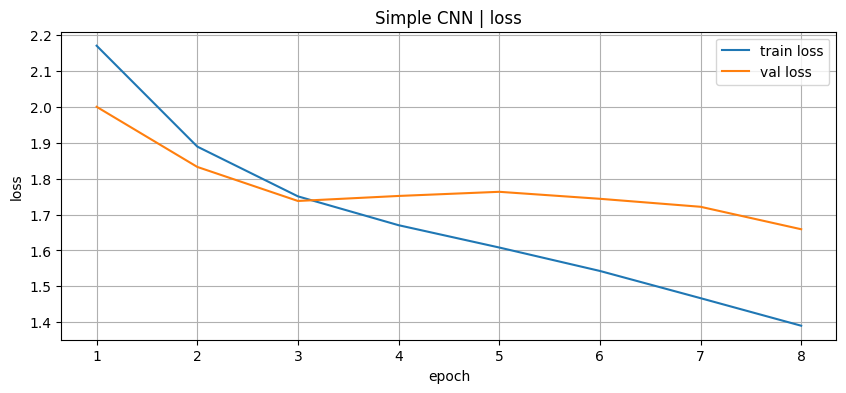

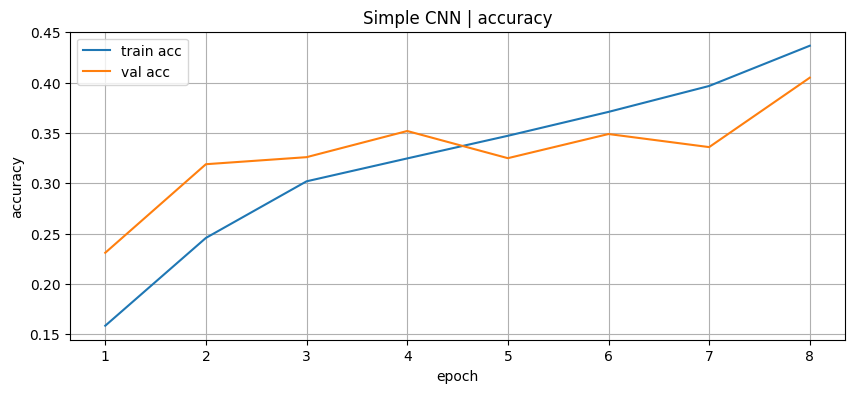

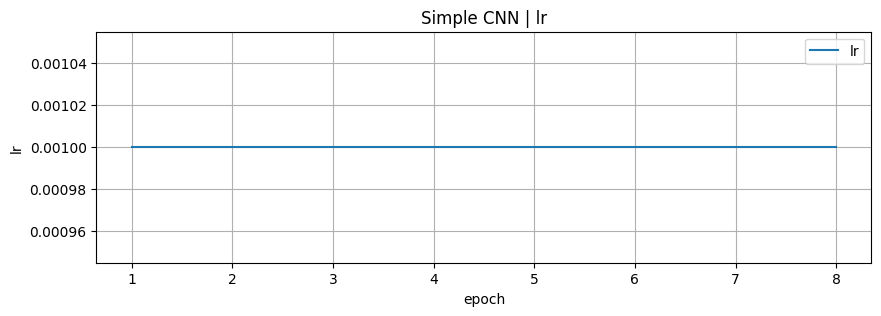

In [19]:
res_cnn_simple = run_experiment("CNN_simple", SimpleCNN(NUM_CLASSES), train_loader, val_loader, lr=1e-3, epochs=EPOCHS)
plot_history(res_cnn_simple["history"], title="Simple CNN")


Experiment CNN_aug | lr=0.001 weight_decay=0.0 epochs=8
Trainable params: 3937122
Epoch 01/8 | lr 1.00e-03 | train loss 2.2581, acc 0.099 | val loss 2.1203, acc 0.152 | 34.5s
Epoch 02/8 | lr 1.00e-03 | train loss 1.9385, acc 0.250 | val loss 1.9311, acc 0.270 | 24.6s
Epoch 03/8 | lr 1.00e-03 | train loss 1.8064, acc 0.302 | val loss 1.8125, acc 0.317 | 25.1s
Epoch 04/8 | lr 1.00e-03 | train loss 1.6916, acc 0.334 | val loss 1.7619, acc 0.339 | 25.0s
Epoch 05/8 | lr 1.00e-03 | train loss 1.6262, acc 0.363 | val loss 1.7375, acc 0.343 | 24.7s
Epoch 06/8 | lr 1.00e-03 | train loss 1.5685, acc 0.389 | val loss 1.8135, acc 0.352 | 23.9s
Epoch 07/8 | lr 1.00e-03 | train loss 1.5306, acc 0.409 | val loss 1.6161, acc 0.389 | 23.6s
Epoch 08/8 | lr 1.00e-03 | train loss 1.4978, acc 0.417 | val loss 1.6654, acc 0.383 | 24.5s


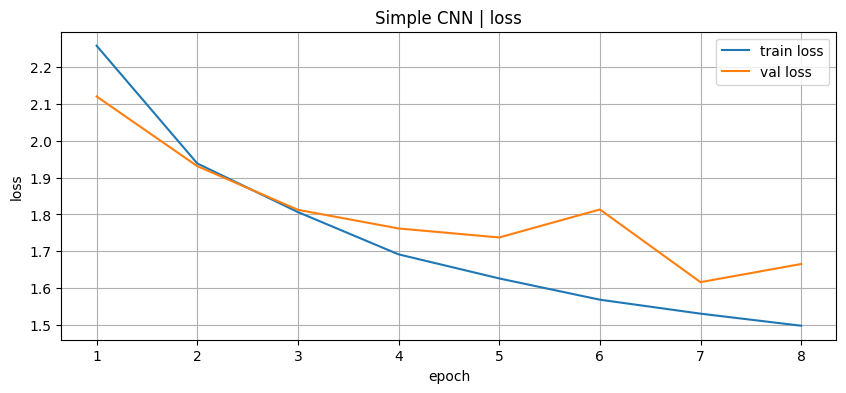

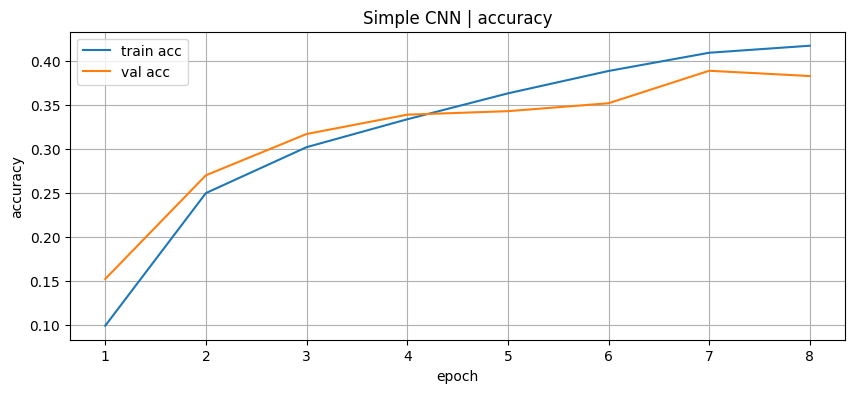

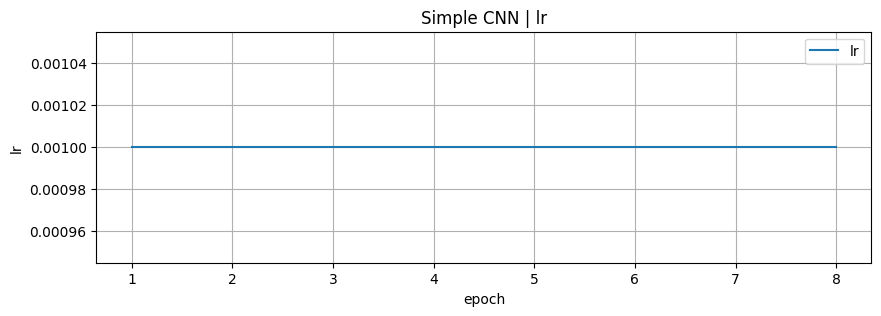

In [20]:
res_cnn_aug = run_experiment("CNN_aug", SimpleCNN(NUM_CLASSES), train_loader_aug, val_loader_aug, lr=1e-3, epochs=EPOCHS)
plot_history(res_cnn_aug["history"], title="Simple CNN")

Trainable params (head-only): 5130

Phase 1: head-only training
Epoch 01/8 | lr 1.00e-03 | train loss 1.3975, acc 0.557 | val loss 0.7970, acc 0.780 | 114.9s
Epoch 02/8 | lr 1.00e-03 | train loss 0.7803, acc 0.771 | val loss 0.6367, acc 0.797 | 116.5s
Epoch 03/8 | lr 1.00e-03 | train loss 0.6776, acc 0.785 | val loss 0.5620, acc 0.818 | 119.5s
Epoch 04/8 | lr 1.00e-03 | train loss 0.6184, acc 0.799 | val loss 0.5402, acc 0.825 | 116.1s
Epoch 05/8 | lr 1.00e-03 | train loss 0.5816, acc 0.812 | val loss 0.5095, acc 0.832 | 116.0s
Epoch 06/8 | lr 1.00e-03 | train loss 0.5550, acc 0.818 | val loss 0.4955, acc 0.838 | 115.9s
Epoch 07/8 | lr 1.00e-03 | train loss 0.5368, acc 0.818 | val loss 0.4926, acc 0.840 | 115.4s
Epoch 08/8 | lr 1.00e-03 | train loss 0.5192, acc 0.828 | val loss 0.4795, acc 0.850 | 121.1s


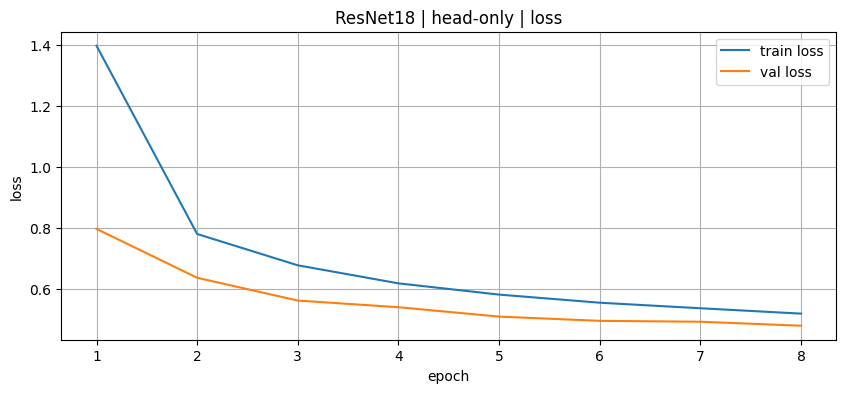

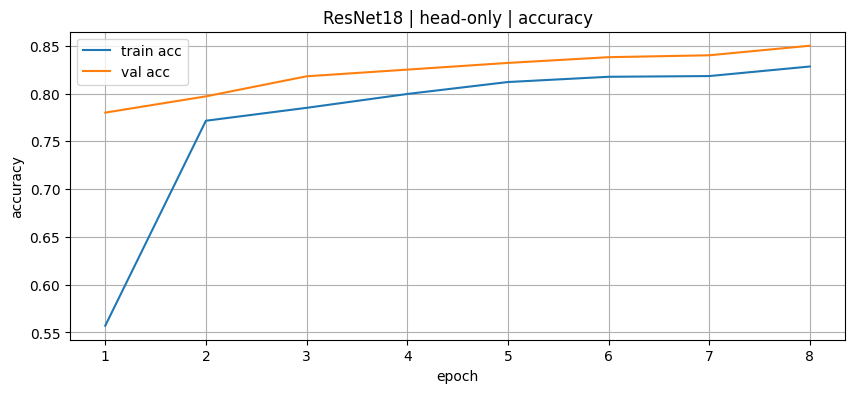

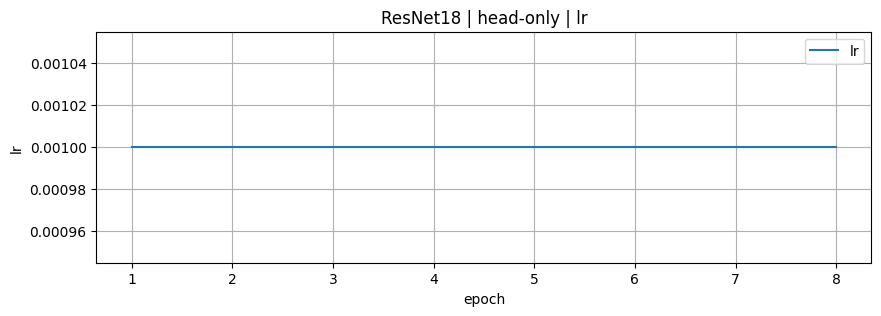

In [21]:
criterion = nn.CrossEntropyLoss()

model_head = build_resnet18(num_classes=10, weights=weights).to(DEVICE)

set_requires_grad(model_head, False)
set_requires_grad(model_head.fc, True)

print("Trainable params (head-only):", count_trainable_params(model_head))

optimizer_head = torch.optim.Adam(model_head.fc.parameters(), lr=1e-3)

print("\n" + "=" * 80)
print("Phase 1: head-only training")
hist_head = fit(model_head, train_loader_aug, val_loader_aug, optimizer_head, criterion, epochs=EPOCHS, verbose=True)
plot_history(hist_head, title="ResNet18 | head-only")

Trainable params (head-only): 5130

Phase 1: head-only training
Epoch 01/8 | lr 1.00e-03 | train loss 1.4979, acc 0.516 | val loss 0.8577, acc 0.766 | 117.0s
Epoch 02/8 | lr 1.00e-03 | train loss 0.8109, acc 0.756 | val loss 0.6720, acc 0.803 | 115.5s
Epoch 03/8 | lr 1.00e-03 | train loss 0.6851, acc 0.789 | val loss 0.5795, acc 0.820 | 120.8s
Epoch 04/8 | lr 1.00e-03 | train loss 0.6316, acc 0.800 | val loss 0.5484, acc 0.828 | 115.4s
Epoch 05/8 | lr 1.00e-03 | train loss 0.5788, acc 0.817 | val loss 0.5155, acc 0.836 | 116.1s
Epoch 06/8 | lr 1.00e-03 | train loss 0.5485, acc 0.822 | val loss 0.5110, acc 0.836 | 116.2s
Epoch 07/8 | lr 1.00e-03 | train loss 0.5566, acc 0.817 | val loss 0.5187, acc 0.829 | 116.0s
Epoch 08/8 | lr 1.00e-03 | train loss 0.5208, acc 0.825 | val loss 0.4879, acc 0.839 | 117.0s


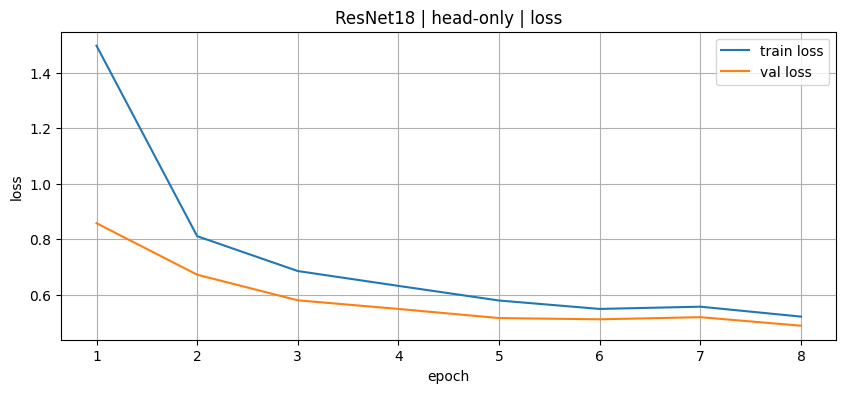

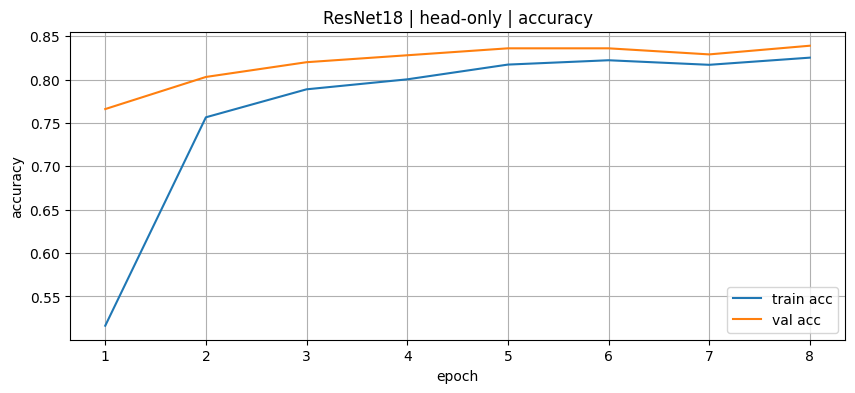

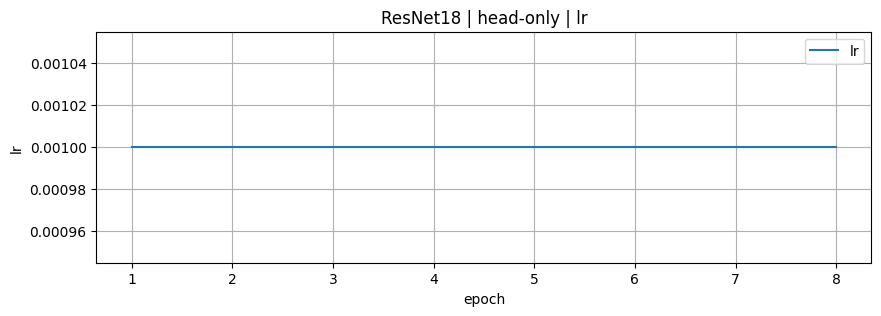

In [23]:
criterion = nn.CrossEntropyLoss()

model_ft = build_resnet18(num_classes=10, weights=weights).to(DEVICE)

set_requires_grad(model_ft, False)
set_requires_grad(model_ft.fc, True)

print("Trainable params (head-only):", count_trainable_params(model_ft))

optimizer_head = torch.optim.Adam(model_ft.fc.parameters(), lr=1e-3)

print("\n" + "=" * 80)
print("Phase 1: head-only training")
hist_head = fit(model_ft, train_loader_aug, val_loader_aug, optimizer_head, criterion, epochs=EPOCHS, verbose=True)
plot_history(hist_head, title="ResNet18 | head-only")

Trainable params (layer4+fc): 8398858

Phase 2: fine-tuning layer4 + fc
Epoch 01/8 | lr 1.00e-04 | train loss 0.4649, acc 0.832 | val loss 0.3711, acc 0.876 | 169.3s
Epoch 02/8 | lr 1.00e-04 | train loss 0.2458, acc 0.920 | val loss 0.3422, acc 0.889 | 176.9s
Epoch 03/8 | lr 1.00e-04 | train loss 0.1658, acc 0.943 | val loss 0.3643, acc 0.886 | 175.8s
Epoch 04/8 | lr 1.00e-04 | train loss 0.1042, acc 0.967 | val loss 0.3056, acc 0.900 | 174.7s
Epoch 05/8 | lr 1.00e-04 | train loss 0.0934, acc 0.972 | val loss 0.3441, acc 0.900 | 173.9s
Epoch 06/8 | lr 1.00e-04 | train loss 0.0803, acc 0.975 | val loss 0.3567, acc 0.893 | 170.9s
Epoch 07/8 | lr 1.00e-04 | train loss 0.0612, acc 0.980 | val loss 0.3451, acc 0.900 | 174.8s
Epoch 08/8 | lr 1.00e-04 | train loss 0.0544, acc 0.980 | val loss 0.3293, acc 0.899 | 170.2s


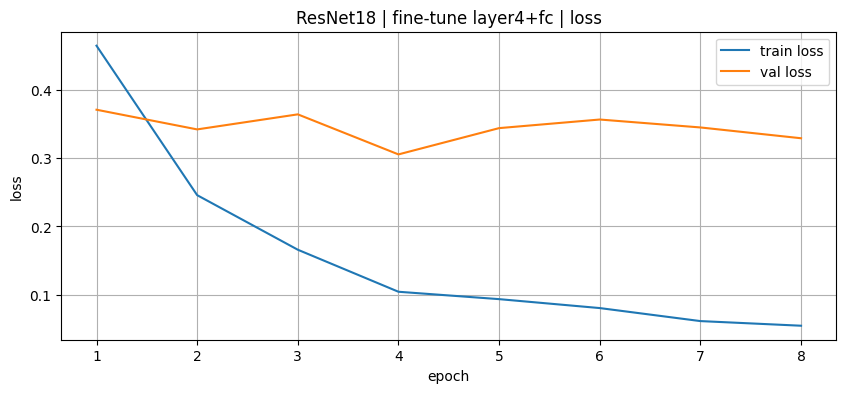

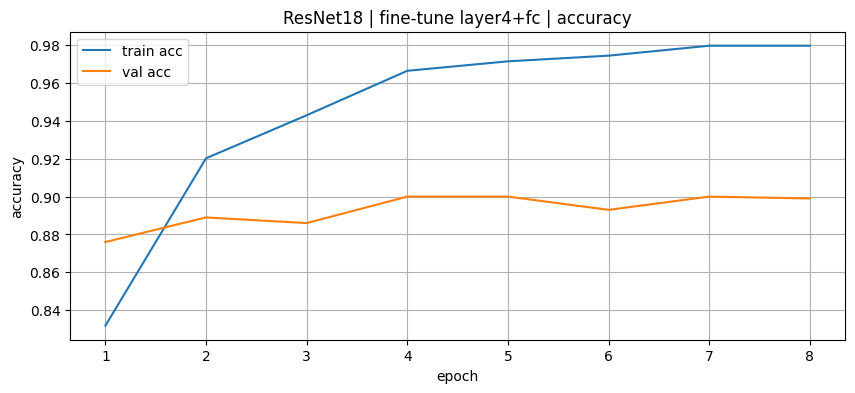

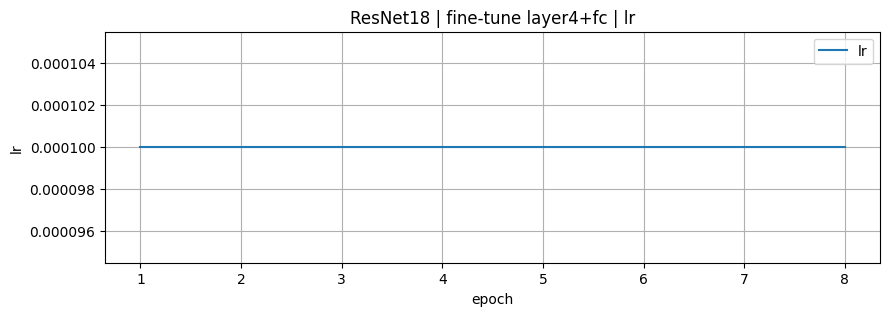

In [24]:
set_requires_grad(model_ft.layer4, True)
set_requires_grad(model_ft.fc, True)

print("Trainable params (layer4+fc):", count_trainable_params(model_ft))

params = [
    {"params": model_ft.layer4.parameters(), "lr": 1e-4},
    {"params": model_ft.fc.parameters(), "lr": 1e-3},
]

optimizer_ft = torch.optim.Adam(params, weight_decay=1e-4)

print("\n" + "=" * 80)
print("Phase 2: fine-tuning layer4 + fc")
hist_ft = fit(model_ft, train_loader_aug, val_loader_aug, optimizer_ft, criterion, epochs=EPOCHS, verbose=True)
plot_history(hist_ft, title="ResNet18 | fine-tune layer4+fc")

In [25]:
print(res_cnn_simple["best_val_acc"])
print(res_cnn_aug["best_val_acc"])
print(float(np.nanmax(hist_head["val_acc"])))
print(float(np.nanmax(hist_ft["val_acc"])))

res = [res_cnn_simple["best_val_acc"],      res_cnn_aug["best_val_acc"], float(np.nanmax(hist_head["val_acc"])), float(np.nanmax(hist_ft["val_acc"]))
]

if max(res) == res[0]:
    best_model = res_cnn_simple["model"]
    best_history = res_cnn_simple["history"]
    print("лучшая модель: C1")
    print("val_acc: ", res[0])
if max(res) == res[1]:
    best_model = res_cnn_aug["model"]
    best_history = res_cnn_aug["history"]
    print("лучшая модель: С2")
    print("val_acc: ", res[1])
if max(res) == res[2]:
    best_model = model_head
    best_history = hist_head
    print("лучшая модель: C3")
    print("val_acc: ", res[2])
else:
    best_model = model_ft
    best_history = hist_ft
    print("лучшая модель: С4")
    print("val_acc: ", res[3])

0.405
0.389
0.839
0.9
лучшая модель: С4
val_acc:  0.9


In [26]:
@torch.no_grad()
def accuracy_on_loader(model, loader) -> float:
    model.eval()
    total_correct, total_seen = 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += y.size(0)
    return total_correct / total_seen

test_acc_best = accuracy_on_loader(best_model, test_loader)
print("Test acc best model:", round(test_acc_best, 4))

Test acc best model: 0.879


In [27]:
weights = DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1
model = deeplabv3_resnet50(weights=weights)
model.to(DEVICE)
model.eval()

categories = weights.meta.get("categories", None)
if categories is None:
    raise RuntimeError("В weights.meta нет списка categories – сложно найти индекс 'person' динамически.")

if "person" not in categories:
    raise RuntimeError("В categories нет класса 'person'. Проверьте, какие веса вы загрузили.")

PERSON_IDX = categories.index("person")
print("num_classes:", len(categories))
print("PERSON_IDX:", PERSON_IDX)

preprocess = weights.transforms()
preprocess

Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth


100%|██████████| 161M/161M [00:01<00:00, 157MB/s]


num_classes: 21
PERSON_IDX: 15


SemanticSegmentation(
    resize_size=[520]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [28]:
PERSON_IDX = 15
IGNORE_IDX = 255

@torch.no_grad()
def predict_person_mask(img_tensor: torch.Tensor):
    """
    img_tensor: torch.Tensor [3,H,W], уже нормализованный (как в ds_val)
    Возвращает:
      pred_person: torch.uint8 [H,W] (0/1)
      (H, W): размер пространства модели
    """
    x = img_tensor.unsqueeze(0).to(DEVICE)
    out = model(x)["out"][0]
    pred = out.argmax(dim=0)
    pred_person = (pred == PERSON_IDX).to(torch.uint8).cpu()
    return pred_person, x.shape[-2:]

def predict_person_mask_v2(img_tensor: torch.Tensor, thr: float = 0.5):
    x = img_tensor.unsqueeze(0).to(DEVICE)
    out = model(x)["out"][0]
    probs = torch.softmax(out, dim=0)
    person_prob = probs[PERSON_IDX]
    pred_person = (person_prob >= thr).to(torch.uint8).cpu()
    return pred_person, x.shape[-2:]

def iou_binary(pred: torch.Tensor, gt: torch.Tensor) -> float:
    pred = pred.bool()
    gt = gt.bool()
    inter = (pred & gt).sum().item()
    union = (pred | gt).sum().item()
    return float(inter / (union + 1e-9))

def eval_subset(indices: List[int]) -> Dict[str, float]:
    ious = []

    for idx in indices:
        img_tensor, gt_mask = ds_val[idx]

        pred_mask, (h, w) = predict_person_mask(img_tensor)

        gt_mask = gt_mask.cpu()
        if gt_mask.shape[-2:] != (h, w):
            gt_rs = F.resize(
                gt_mask.unsqueeze(0).to(torch.uint8),
                size=[h, w],
                interpolation=InterpolationMode.NEAREST,
            ).squeeze(0).to(torch.int64)
        else:
            gt_rs = gt_mask.to(torch.int64)

        ignore = (gt_rs == IGNORE_IDX)
        gt_person = (gt_rs == PERSON_IDX).to(torch.uint8)

        iou = iou_binary(pred_mask, gt_person)
        if not np.isnan(iou):
            ious.append(iou)

    return {
        "n": float(len(ious)),
        "mean_IoU": float(np.mean(ious)) if len(ious) else float("nan"),
        "median_IoU": float(np.median(ious)) if len(ious) else float("nan"),
        "min_IoU": float(np.min(ious)) if len(ious) else float("nan"),
        "max_IoU": float(np.max(ious)) if len(ious) else float("nan"),
        "ious": ious,
    }

def eval_subset_v2(indices: List[int], thr: float = 0.5) -> Dict[str, float]:
    ious = []
    for idx in indices:
        img_tensor, gt_mask = ds_val[idx]
        pred_mask, (h, w) = predict_person_mask_v2(img_tensor, thr=thr)

        gt_mask = gt_mask.cpu()
        if gt_mask.shape[-2:] != (h, w):
            gt_rs = F.resize(
                gt_mask.unsqueeze(0).to(torch.uint8),
                size=[h, w],
                interpolation=InterpolationMode.NEAREST,
            ).squeeze(0).to(torch.int64)
        else:
            gt_rs = gt_mask.to(torch.int64)

        gt_person = (gt_rs == PERSON_IDX).to(torch.uint8)
        iou = iou_binary(pred_mask, gt_person)
        if not np.isnan(iou):
            ious.append(iou)

    return {
        "n": float(len(ious)),
        "mean_IoU": float(np.mean(ious)) if len(ious) else float("nan"),
        "median_IoU": float(np.median(ious)) if len(ious) else float("nan"),
        "min_IoU": float(np.min(ious)) if len(ious) else float("nan"),
        "max_IoU": float(np.max(ious)) if len(ious) else float("nan"),
        "ious": ious,
    }

eval_indices = list(range(len(ds_val)))

v1 = eval_subset(eval_indices)
v2 = eval_subset_v2(eval_indices, thr=0.35)

print("V1:", {k: v1[k] for k in ["n", "mean_IoU", "median_IoU", "min_IoU", "max_IoU"]})
print("V2 (thr=0.35):", {k: v2[k] for k in ["n", "mean_IoU", "median_IoU", "min_IoU", "max_IoU"]})

V1: {'n': 1449.0, 'mean_IoU': 0.13494840376595277, 'median_IoU': 0.0, 'min_IoU': 0.0, 'max_IoU': 0.967437519444056}
V2 (thr=0.35): {'n': 1449.0, 'mean_IoU': 0.13244339721409648, 'median_IoU': 0.0, 'min_IoU': 0.0, 'max_IoU': 0.9600326264273082}


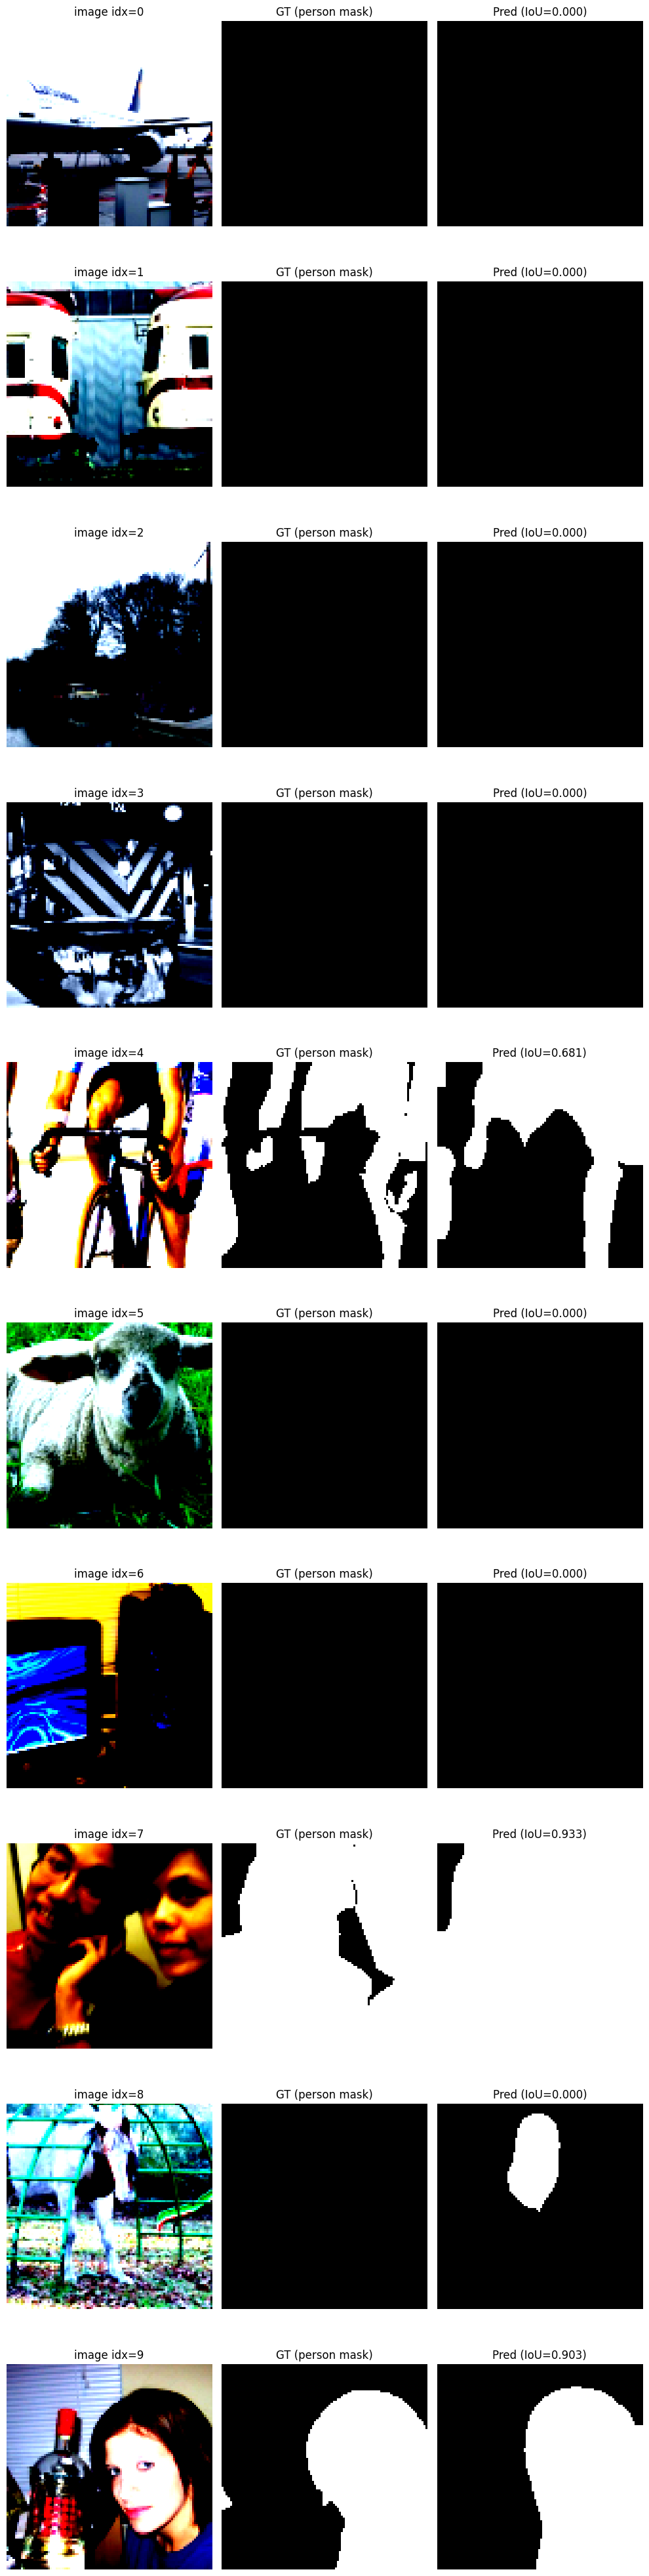

In [30]:
n = min(10, len(ds_val))
fig, axes = plt.subplots(n, 3, figsize=(10, 4 * n))

if n == 1:
    axes = np.expand_dims(axes, axis=0)

for row in range(n):
    img_tensor, gt_tensor = ds_val[row]
    pred_mask, (h, w) = predict_person_mask(img_tensor)

    gt_tensor = gt_tensor.cpu()
    if gt_tensor.shape[-2:] != (h, w):
        gt_rs = F.resize(
            gt_tensor.unsqueeze(0).to(torch.uint8),
            size=[h, w],
            interpolation=InterpolationMode.NEAREST
        ).squeeze(0).to(torch.int64)
    else:
        gt_rs = gt_tensor.to(torch.int64)

    gt_mask = (gt_rs == PERSON_IDX).to(torch.uint8)
    iou = iou_binary(pred_mask, gt_mask)

    img_show = img_tensor.detach().cpu().permute(1, 2, 0).numpy()
    img_show = np.clip(img_show, 0.0, 1.0)

    axes[row, 0].imshow(img_show)
    axes[row, 0].set_title(f"image idx={row}")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(gt_mask.numpy(), cmap="gray")
    axes[row, 1].set_title("GT (person mask)")
    axes[row, 1].axis("off")

    axes[row, 2].imshow(pred_mask.numpy(), cmap="gray")
    axes[row, 2].set_title(f"Pred (IoU={iou:.3f})")
    axes[row, 2].axis("off")

plt.tight_layout()
plt.savefig("artifacts/figures/segmentation_examples.png")
plt.show()

In [31]:
best_val_acc_c1 = float(res_cnn_simple["best_val_acc"])

best_val_acc_c2 = float(res_cnn_aug["best_val_acc"])

best_val_acc_c3 = float(np.nanmax(hist_head["val_acc"])) if len(hist_head["val_acc"]) else float("nan")

best_val_acc_c4 = float(np.nanmax(hist_ft["val_acc"])) if len(hist_ft["val_acc"]) else float("nan")

In [32]:
runs = pd.DataFrame({
    'experiment_id': ['C1', 'C2', 'C3', 'C4', 'V1', 'V2'],
    'task': ['classification', 'classification', 'classification', 'classification', 'segmentation', 'segmentation'],
    'dataset': ['STL10', 'STL10', 'STL10', 'STL10', 'VOCSegmentation', 'VOCSegmentation'],
    'seed': [42, 42, 42, 42, 42, 42],
    'model_summary': [
        'SimpleCNN: [Conv(3->8,k3,s2,p1)-ReLU] -> [Conv(8->16,k3,s2,p1)-ReLU] -> [Conv(16->32,k3,s2,p1)-ReLU] -> [Conv(32->64,k3,s2,p1)-ReLU] -> [Conv(64->128,k3,s2,p1)-ReLU] -> [Conv(128->256,k3,s2,p1)-ReLU] -> [Conv(256->512,k3,s2,p1)-ReLU] -> [Conv(512->512,k3,s2,p1)-ReLU] -> AdaptiveAvgPool(1x1) -> Flatten(512x1x1) -> FC(512->10)',
        'SimpleCNN: [Conv(3->8,k3,s2,p1)-ReLU] -> [Conv(8->16,k3,s2,p1)-ReLU] -> [Conv(16->32,k3,s2,p1)-ReLU] -> [Conv(32->64,k3,s2,p1)-ReLU] -> [Conv(64->128,k3,s2,p1)-ReLU] -> [Conv(128->256,k3,s2,p1)-ReLU] -> [Conv(256->512,k3,s2,p1)-ReLU] -> [Conv(512->512,k3,s2,p1)-ReLU] -> AdaptiveAvgPool(1x1) -> Flatten(512x1x1) -> FC(512->10)',
        'resnet18, model.fc = nn.Linear(model.fc.in_features, 10)',
        'resnet18, model.fc = nn.Linear(model.fc.in_features, 10)',
        'DeepLabV3 (COCO-with-VOC-labels)',
        'DeepLabV3 (COCO-with-VOC-labels)',
    ],
    'optimizer': ['Adam', 'Adam', 'Adam', 'Adam', 'Adam', 'Adam'],
    'lr': [1e-3, 1e-3, 1e-3, (1e-4, 1e-3), 1e-3, 1e-3],
    'epochs_trained': [8, 8, 8, 8, "", ""],
    'best_val_accuracy': [best_val_acc_c1, best_val_acc_c2, best_val_acc_c3, best_val_acc_c4, "", ""],
    'test_accuracy': ["", "", "", round(test_acc_best, 4), "", ""],
    'precision': ["", "", "", "", "", ""],
    'recall': ["", "", "", "", "", ""],
    'mean_iou': ["", "", "", "", v1["mean_IoU"], v2["mean_IoU"]],
    'notes': ["", "", "", "", "", ""]
})

In [33]:
runs.to_csv('artifacts/runs.csv', index=False)

torch.save(best_model.state_dict(), 'artifacts/best_classifier.pt')

best_classifier_config = {
    'dataset': 'STL10',
    'architecture': 'resnet18, model.fc = nn.Linear(model.fc.in_features, 10)',
    'transforms': {
        'train_tf_aug': 'Resize(IMG_SIZE + 32) - RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)) - RandomHorizontalFlip(p=0.5) - ToTensor() - Normalize(STL10_MEAN, STL10_STD)',
        'eval_tf': 'Resize(IMG_SIZE + 32) - CenterCrop(IMG_SIZE) - ToTensor() - Normalize(STL10_MEAN, STL10_STD)',
    },
    'activation': 'relu',
    'dropout': 0,
    'batchnorm': True,
    'early_stopping': True,
    'optimizer': 'Adam',
    'lr': 1e-3,
    'criterion': 'CrossEntropyLoss',
    'epochs_trained': 8,
    'seed': 42,
}
with open("artifacts/best_classifier_config.json", "w") as f:
    json.dump(best_classifier_config, f, indent=4)

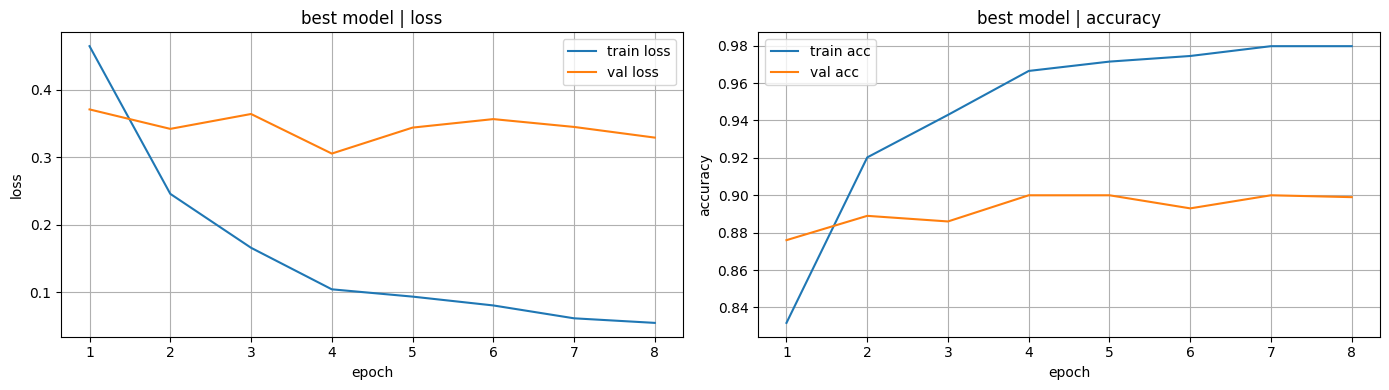

In [34]:
plot_history_with_save(best_history, title="best model", title_save='classification_curves_best.png')

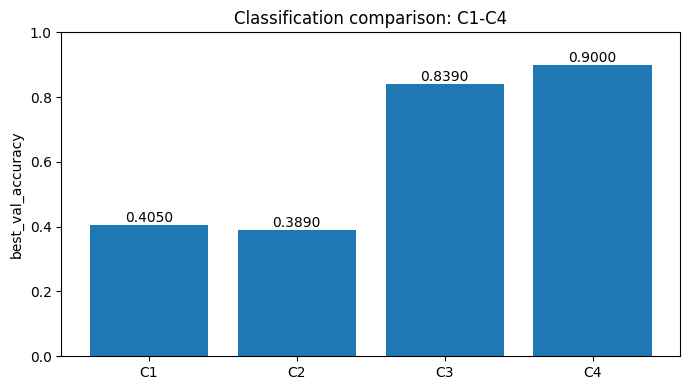

In [35]:
labels = ["C1", "C2", "C3", "C4"]
values = [best_val_acc_c1, best_val_acc_c2, best_val_acc_c3, best_val_acc_c4]

plt.figure(figsize=(7, 4))
bars = plt.bar(labels, values)

for bar, v in zip(bars, values):
    if np.isfinite(v):
        plt.text(bar.get_x() + bar.get_width() / 2, v, f"{v:.4f}", ha="center", va="bottom")

plt.ylabel("best_val_accuracy")
plt.title("Classification comparison: C1-C4")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("artifacts/figures/classification_compare.png", dpi=150)
plt.show()

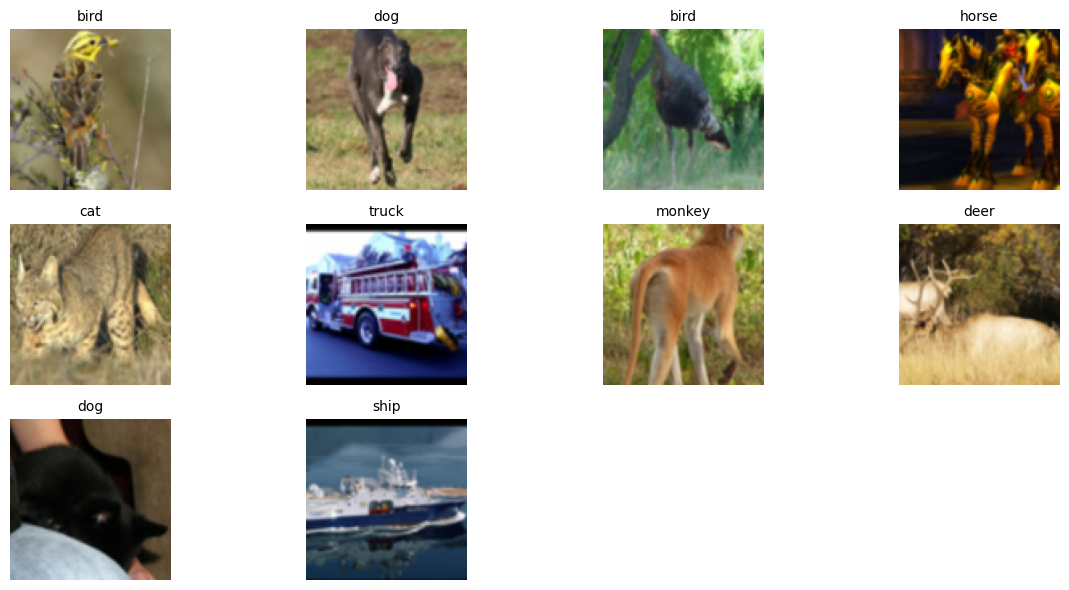

In [36]:
n_images = 10
n_cols = 4
n_rows = math.ceil(n_images / n_cols)

plt.figure(figsize=(12, 6))

for i in range(n_images):
    img, label = ds_train_aug[i]
    mean = torch.tensor(STL10_MEAN).view(3, 1, 1)
    std = torch.tensor(STL10_STD).view(3, 1, 1)
    img_vis = (img * std + mean).clamp(0, 1)
    img_vis = img_vis.permute(1, 2, 0).cpu().numpy()

    ax = plt.subplot(n_rows, n_cols, i + 1)
    ax.imshow(img_vis)
    ax.set_title(class_names[label], fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.savefig("artifacts/figures/augmentations_preview.png", dpi=150)
plt.show()

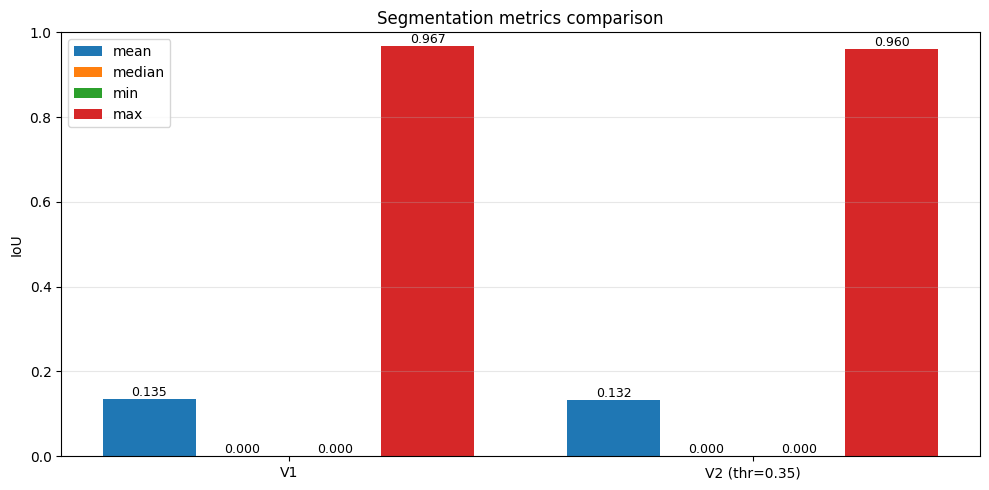

In [37]:
labels = ["V1", "V2 (thr=0.35)"]
mean_vals = [v1["mean_IoU"], v2["mean_IoU"]]
median_vals = [v1["median_IoU"], v2["median_IoU"]]
min_vals = [v1["min_IoU"], v2["min_IoU"]]
max_vals = [v1["max_IoU"], v2["max_IoU"]]

x = np.arange(len(labels))
w = 0.2

plt.figure(figsize=(10, 5))
b1 = plt.bar(x - 1.5 * w, mean_vals, width=w, label="mean")
b2 = plt.bar(x - 0.5 * w, median_vals, width=w, label="median")
b3 = plt.bar(x + 0.5 * w, min_vals, width=w, label="min")
b4 = plt.bar(x + 1.5 * w, max_vals, width=w, label="max")

for bars in [b1, b2, b3, b4]:
    for bar in bars:
        h = bar.get_height()
        if np.isfinite(h):
            plt.text(bar.get_x() + bar.get_width() / 2, h, f"{h:.3f}", ha="center", va="bottom", fontsize=9)

plt.xticks(x, labels)
plt.ylabel("IoU")
plt.ylim(0, 1)
plt.title("Segmentation metrics comparison")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("artifacts/figures/segmentation_metrics.png", dpi=150)
plt.show()